In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn
import seaborn.objects as so
import plot
from common import sweep
from joint import independent_binlets, joint_binlets, build_signal

In [2]:
def generate_vectors(snr_big, snr_small, *, n=4):
    delta = np.arctan2(snr_big, snr_small)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    angles += delta
    points = snr_big * np.exp(1j * angles)
    return points.view(float).reshape(n, 2)

In [3]:
def chi2(snr, delta, repeats=100):
    vectors = generate_vectors(snr, delta)
    x_true = build_signal(vectors, size=256, segment_size=6)
    rng = np.random.default_rng(42)
    return sweep(
        sigmas=np.linspace(0, 8, 15),
        x_true=x_true,
        x_var_true=1,
        measure_func=rng.normal,
        binlets_funcs={
            "independent": independent_binlets,
            "joint": joint_binlets,
        },
        repeats=repeats,
    ).assign(snr=snr, delta=delta)


df = chi2(5, 2)

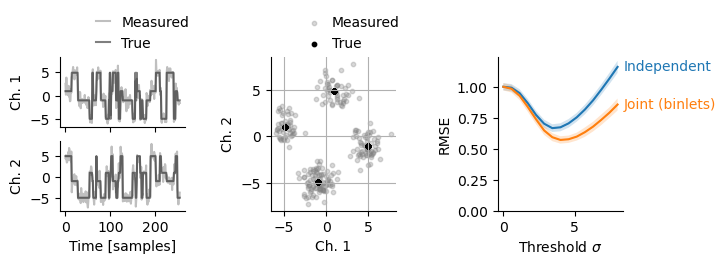

In [4]:
class Colors:
    true = "black"
    noisy = "gray"
    independent = "C0"
    joint = "C1"


def panel_signal(fig_signal, fig_vector):
    vectors = generate_vectors(5, 1, n=4)
    signal_true = build_signal(vectors, size=256, segment_size=6)
    signal_noisy = np.random.normal(signal_true)

    ax = fig_vector.subplots()
    ax.scatter(*signal_noisy, s=10, alpha=0.3, color=Colors.noisy)
    ax.scatter(*signal_true, s=10, color=Colors.true)
    ax.grid()
    ax.set(xlabel="Ch. 1", ylabel="Ch. 2")

    ax_temporal = fig_signal.subplots(nrows=2, sharex=True)
    for color, signal in [
        (Colors.noisy, signal_noisy),
        (Colors.true, signal_true),
    ]:
        for ax, channel in zip(ax_temporal, signal):
            ax.plot(channel, alpha=0.5, color=color)

    ax_temporal[0].set(ylabel="Ch. 1")
    ax_temporal[1].set(ylabel="Ch. 2", xlabel="Time [samples]")


def panel_chi(fig, df):
    (
        so.Plot(df, x="sigma", y="RMSE", color="variant")
        .label(y="RMSE", x="Threshold $\sigma$")
        .add(so.Line(), so.Est())
        .add(so.Band(alpha=1), so.Est(errorbar="se"))
        .add(so.Band(), so.Est(errorbar="sd"))
        .scale(color=so.Nominal())
        .limit(y=(0, None))
        .theme(plt.rcParams)
        .on(fig)
        .plot()
    )


fig = plt.figure(figsize=(6, 2))
figs = fig.subfigures(1, 5, width_ratios=[1, 0.3, 1, 0.4, 1])
panel_signal(figs[0], figs[2])
panel_chi(figs[-1], df)
fig.legends = []
seaborn.despine(fig)
plot.label_lines(figs[-1].axes[0], labels=["Independent", "Joint (binlets)"])
for f in (figs[0], figs[2]):
    f.legend(
        ["Measured", "True"],
        frameon=False,
        handlelength=1,
        bbox_to_anchor=(1, 1),
        loc="center right",
    )

path = "../article/figures/3_joint"
fig.savefig(path + ".png", bbox_inches="tight")
fig.savefig(path + ".pdf", bbox_inches="tight")

In [5]:
improvement = (
    1
    / df.groupby(["sigma", "variant"])
    .RMSE.mean()
    .reset_index()
    .groupby(["variant"])
    .RMSE.min()
)
improvement["ratio"] = np.divide(*improvement[::-1])

improvement

variant
independent    1.498317
joint          1.748102
ratio          1.166710
Name: RMSE, dtype: float64